###

We implement and solve the ‘navigate and recharge’ task (see also book p. 135). The robot is
placed in an empty arena (no walls). At one corner there is a lamp and the floor at that corner
is painted black within a quadrant. This black area represents the charging area. The robot has
a simulated battery level b ∈ [0, bmax] that is immediately recharged (b = bmax) once the robot
enters the black area. We assume a fast linear discharge rate. The robot has three proximity
sensors (to the front, 90◦ to the left, 90◦ to the right), two ambient light sensors (one at the
front, one at the back, they are sensing a light intensity field similar to the Braitenberg vehicles
in tutorial 1), one ground sensor (discrete, 0 for black, 1 for non-black), and a sensor that gives
the battery level. Implement an ANN with hidden layer. You can choose any number of hidden
neurons, preferentially between 2 and 5. For this task it might be advantageous to implement
a recurrent network. To do so, you can provide each hidden neuron with its activation of the
previous time step (as net input in addition to the regular inputs and multiplied with a dedicated
weight).
The fitness function is generally defined by:


Φ = V (1 − i)


with 0 ≤ V, i ≤ 1. 


V is the average rotation speed of both wheels. 

i is the average activation level
of the sensors (i ≈ 0 means no close-by objects, i ≈ 1 means many close-by objects).


However, Whenever the robot is positioned on the charging area it receives no fitness for that period.
Try to find good parameters for robot speed, discharging rate, size of the charging area, maximal
battery level bmax, arena dimensions, proximity sensor range, maximal evaluation time, etc.
Remember that they need to relate to each other in an appropriate way to provoke the evolution
of interesting behaviors (e.g., an excessively high robot speed combined with a very large
maximum battery level makes the task trivial). You might want to base the fitness value on
several independent evaluations with random initial positions. Consider also to add a little noise
to the motor control values to avoid too simple behavioral patterns.
Prepare for long computations as the problem is hard and many evaluations will be needed. Try
different settings until you are able to evolve a good behavior. Test your best controller after
evolution has been done for different starting positions. Does it manage to reach the charging
area from many different initial positions?



**Starting Evolution - Genome Size: 58 weights**
--- Starting Evolutionary Algorithm ---

--- Generation 1/500 (32.66s) ---
BEST Fitness: 0.42663, Average Fitness: 0.06102

--- Generation 2/500 (38.22s) ---
BEST Fitness: 0.37416, Average Fitness: 0.07734

--- Generation 3/500 (49.35s) ---
BEST Fitness: 0.27305, Average Fitness: 0.07811

--- Generation 4/500 (57.79s) ---
BEST Fitness: 0.52779, Average Fitness: 0.09319

--- Generation 5/500 (53.26s) ---
BEST Fitness: 0.52400, Average Fitness: 0.12513

--- Generation 6/500 (70.67s) ---
BEST Fitness: 0.80642, Average Fitness: 0.18176

--- Generation 7/500 (71.77s) ---
BEST Fitness: 0.74382, Average Fitness: 0.19619

--- Generation 8/500 (97.25s) ---
BEST Fitness: 0.84974, Average Fitness: 0.27673

--- Generation 9/500 (101.58s) ---
BEST Fitness: 0.81711, Average Fitness: 0.29207

--- Generation 10/500 (145.09s) ---
BEST Fitness: 0.82846, Average Fitness: 0.38240
   [CHECKPOINT SAVED at Gen 9]

--- Generation 11/500 (257.65s) ---
BEST Fitne

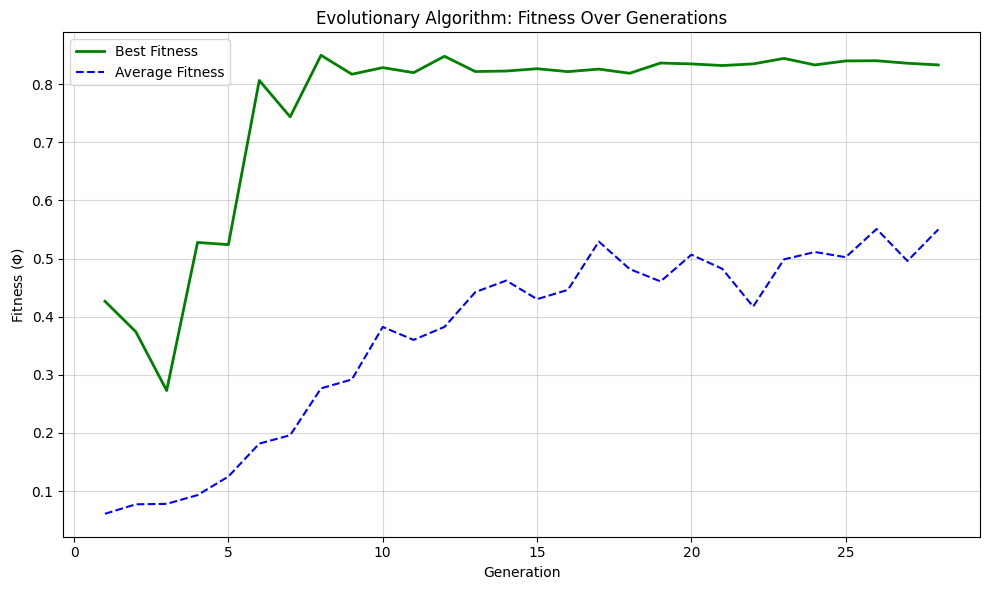

Deliverable 2: Fitness history plot generated.


C:\Users\shazz\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


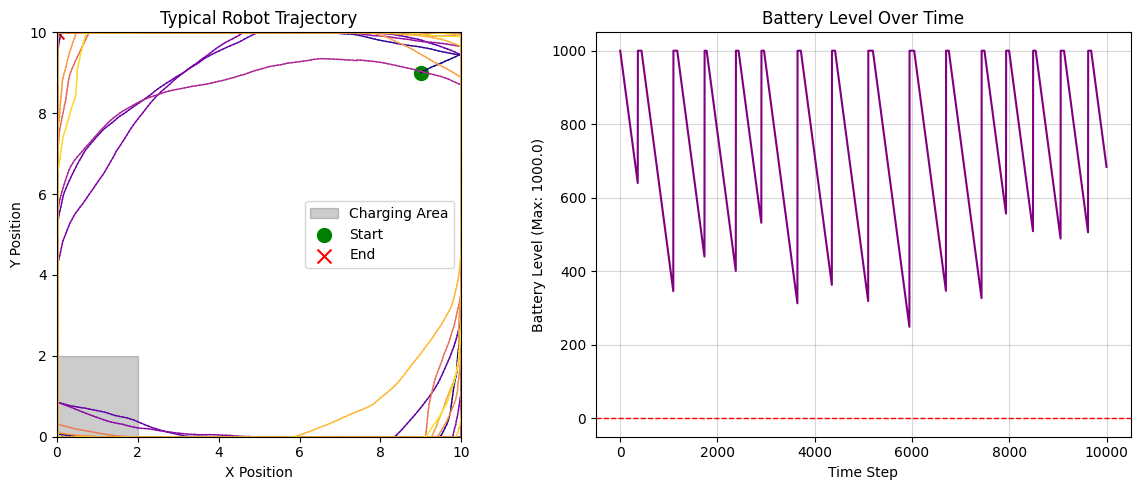

Deliverable 3: Trajectory and battery plots generated.


In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
import pickle
import os

# ------------------------------------------------------------------------------
# EVOLUTIONARY ROBOTICS: SURVIVAL TASK
# This script uses an Evolutionary Algorithm (EA) to train a Recurrent Neural 
# Network (RNN) controlling a robot. The robot must learn to balance exploring 
# for fitness (moving fast) with survival (returning to a charger).
# ------------------------------------------------------------------------------

# --- 1. PARAMETER DEFINITIONS ---
# This section defines the static configuration for the world, the robot, and the AI.
class Params:
    # --- Environment ---
    ARENA_SIZE = 10.0      # The world is a 10x10 square.
    CHARGE_SIZE = 2.0      # The charging zone is a 2x2 square at (0,0).
    LAMP_POS = np.array([0.0, 0.0]) # Light source is centered in the charging zone.
    
    # --- Robot Physics ---
    AXLE_LENGTH = 0.2      # Distance between wheels (kinematics).
    MAX_SPEED = 0.1        # Maximum speed per time step.
    PROX_RANGE = 1.0       # Max detection range for proximity sensors.
    MOTOR_NOISE = 0.01     # Gaussian noise added to motor output for realism.
    
    # --- Battery and Survival ---
    B_MAX = 1000.0         # Max battery capacity.
    D_RATE = 1.0           # Discharge rate per step (1000 steps of life).
    
    # --- ANN Architecture ---
    # The brain is a 7-4-2 Recurrent Neural Network.
    INPU_SIZE = 7        # Inputs: 3 Proximity, 2 Light, 1 Ground, 1 Battery.
    HIDDEN_SIZE = 4        # Hidden Neurons: Process data and store memory.
    OUTPUT_SIZE = 2        # Outputs: Left Wheel Velocity, Right Wheel Velocity.
    
    # --- Evaluation ---
    DELTA_T = 1.0          # Time step size.
    MAX_STEPS = 10000      # Duration of one simulation trial.

class EAParams:
    # --- Evolutionary Algorithm Settings ---
    POP_SIZE = 50          # Number of robots (genomes) in each generation.
    N_ELITE = 5            # Top 5 robots are copied to next gen (Elitism).
    N_GENERATIONS_MAX = 500 # Max duration of the experiment.

    # --- Convergence Parameters for Runtime Optimization ---
    CONV_WINDOW = 20       # Look at the last 20 generations to check for stalls.
    CONV_THRESHOLD = 0.001 # If improvement < 0.001, stop early.
    SAVE_FREQUENCY = 10    # Save progress to disk every 10 generations.
    
    # Mutation Parameters
    MUT_RATE = 0.1         # Probability of mutating a specific gene (weight).
    MUT_STRENGTH = 0.5     # Magnitude of the mutation (Gaussian standard deviation).
    
    # Evaluation
    NUM_TRIALS_PER_GENOME = 5 # Average fitness over 5 runs to reduce luck.

# --- 2. THE RECURRENT NEURAL NETWORK (ANN) ---
# This class acts as the robot's brain.
class ANN:
    """Implements the required recurrent network."""
    def __init__(self, P):
        self.P = P
        # Define matrix dimensions based on 7-4-2 architecture + Bias.
        self.size_w_ih = (P.INPUT_SIZE + 1, P.HIDDEN_SIZE)   # Input-to-Hidden
        self.size_w_hh = (P.HIDDEN_SIZE, P.HIDDEN_SIZE)      # Recurrent (Hidden-to-Hidden)
        self.size_w_ho = (P.HIDDEN_SIZE + 1, P.OUTPUT_SIZE)  # Hidden-to-Output
        
        # Calculate total number of weights (genes) in the genome.
        self.genome_size = (self.size_w_ih[0] * self.size_w_ih[1] + self.size_w_hh[0] * self.size_w_hh[1] + self.size_w_ho[0] * self.size_w_ho[1])
        
        # Initialize hidden state (Short-term Memory) to zeros.
        self.hidden_state = np.zeros(P.HIDDEN_SIZE)
        self.W_ih = self.W_hh = self.W_ho = None

    def load_genome(self, genome):
        # Unpacks the 1D genome array into the 3 weight matrices.
        cursor = 0
        size = self.size_w_ih[0] * self.size_w_ih[1]; self.W_ih = genome[cursor : cursor + size].reshape(self.size_w_ih); cursor += size
        size = self.size_w_hh[0] * self.size_w_hh[1]; self.W_hh = genome[cursor : cursor + size].reshape(self.size_w_hh); cursor += size
        size = self.size_w_ho[0] * self.size_w_ho[1]; self.W_ho = genome[cursor : cursor + size].reshape(self.size_w_ho)
        
    def step(self, sensor_inputs):
        # Performs a forward pass through the network for one time step.
        
        # 1. Hidden Layer (Sigmoid Activation)
        # Includes Recurrence: Previous hidden state is added to current input.
        I_with_bias = np.append(sensor_inputs, 1.0)
        net_ih = I_with_bias @ self.W_ih
        net_hh = self.hidden_state @ self.W_hh
        net_h = net_ih + net_hh
        new_hidden_state = 1.0 / (1.0 + np.exp(-net_h))
        self.hidden_state = new_hidden_state # Update memory for next step
        
        # 2. Output Layer (Tanh Activation)
        # Maps hidden state to motor commands.
        H_with_bias = np.append(new_hidden_state, 1.0)
        net_o = H_with_bias @ self.W_ho
        motor_outputs_normalized = np.tanh(net_o)
        
        # Scale outputs to physical speed limits.
        V_L = motor_outputs_normalized[0] * self.P.MAX_SPEED
        V_R = motor_outputs_normalized[1] * self.P.MAX_SPEED
        
        return np.array([V_L, V_R])

    def reset_state(self):
        # Reset memory between trials.
        self.hidden_state = np.zeros(self.P.HIDDEN_SIZE)

# --- 3. SIMULATOR CLASS ---
# This class simulates the physics, sensors, and survival logic.
class Simulator:
    def __init__(self, P):
        self.P = P
        self.prox_angles = [0.0, np.pi / 2, -np.pi / 2] # Front, Left, Right
        self.light_angles = [0.0, np.pi]                # Front, Back
        self.reset_run()

    def reset_run(self, initial_pose=None):
        # Places robot in random position if none provided.
        if initial_pose is None:
            self.x = np.random.uniform(self.P.CHARGE_SIZE, self.P.ARENA_SIZE - self.P.CHARGE_SIZE)
            self.y = np.random.uniform(self.P.CHARGE_SIZE, self.P.ARENA_SIZE - self.P.CHARGE_SIZE)
            self.theta = np.random.uniform(0, 2 * np.pi)
        else:
            self.x, self.y, self.theta = initial_pose
            
        self.battery = self.P.B_MAX
        self.time_step = 0
        self.is_alive = True
        
    def _is_on_charger(self):
        # Checks if robot is inside the 2x2 charging square.
        return (0 <= self.x <= self.P.CHARGE_SIZE) and (0 <= self.y <= self.P.CHARGE_SIZE)

    def _get_light_intensity(self, sensor_angle):
        # Calculates light intensity (Inverse Square Law).
        global_angle = self.theta + sensor_angle
        sensor_pos = np.array([self.x, self.y]) + 0.1 * np.array([np.cos(global_angle), np.sin(global_angle)])
        d_sq = np.sum((sensor_pos - self.P.LAMP_POS)**2)
        CLIP_DIST_SQ = 0.1**2 
        d_sq = max(d_sq, CLIP_DIST_SQ)
        intensity = 1.0 / d_sq
        I_MAX = 1.0 / CLIP_DIST_SQ
        return min(intensity / I_MAX, 1.0)

    def _get_proximity(self, sensor_angle):
        # Ray-casting to find distance to walls.
        global_angle = self.theta + sensor_angle
        wall_distances = []
        if abs(np.cos(global_angle)) > 1e-6:
            if np.cos(global_angle) > 0: wall_distances.append((self.P.ARENA_SIZE - self.x) / np.cos(global_angle))
            else: wall_distances.append((0.0 - self.x) / np.cos(global_angle))
        if abs(np.sin(global_angle)) > 1e-6:
            if np.sin(global_angle) > 0: wall_distances.append((self.P.ARENA_SIZE - self.y) / np.sin(global_angle))
            else: wall_distances.append((0.0 - self.y) / np.sin(global_angle))
        d_min = min([d for d in wall_distances if d > 1e-6], default=np.inf)
        reading = 1.0 - (d_min / self.P.PROX_RANGE)
        return max(0.0, reading)

    def get_sensors(self):
        # Aggregates all sensor data into a single array for the ANN.
        S_prox = [self._get_proximity(angle) for angle in self.prox_angles]
        S_light = [self._get_light_intensity(angle) for angle in self.light_angles]
        S_ground = 0.0 if self._is_on_charger() else 1.0
        S_battery = self.battery / self.P.B_MAX
        return np.array(S_prox + S_light + [S_ground, S_battery])

    def update_robot(self, motor_outputs):
        if not self.is_alive: return 0.0
        
        # 1. Apply Noise and Clip
        V_L_raw, V_R_raw = motor_outputs
        # Add motor noise to force robust learning.
        V_L = np.clip(V_L_raw + np.random.normal(0, self.P.MOTOR_NOISE), -self.P.MAX_SPEED, self.P.MAX_SPEED)
        V_R = np.clip(V_R_raw + np.random.normal(0, self.P.MOTOR_NOISE), -self.P.MAX_SPEED, self.P.MAX_SPEED)
        
        # 2. Physics Update (Differential Drive)
        V_avg = (V_R + V_L) / 2.0
        omega = (V_R - V_L) / self.P.AXLE_LENGTH
        
        self.x += V_avg * np.cos(self.theta) * self.P.DELTA_T
        self.y += V_avg * np.sin(self.theta) * self.P.DELTA_T
        self.theta += omega * self.P.DELTA_T
        self.theta = self.theta % (2 * np.pi)
        
        self.x = np.clip(self.x, 0.0, self.P.ARENA_SIZE)
        self.y = np.clip(self.y, 0.0, self.P.ARENA_SIZE)
        
        # 3. Battery and Fitness Update
        fitness_contribution = 0.0
        
        if self._is_on_charger():
            self.battery = self.P.B_MAX
            fitness_contribution = 0.0 # No points for sitting on charger.
        else:
            self.battery -= self.P.D_RATE * self.P.DELTA_T
            
            # Required: Phi = V * (1 - i)
            # Fitness reward: Move fast (V) while avoiding obstacles (i).
            V_norm = (np.abs(V_L) + np.abs(V_R)) / (2 * self.P.MAX_SPEED) 
            current_sensors = self.get_sensors()
            i = np.mean(current_sensors[:5]) 
            fitness_contribution = V_norm * (1.0 - i)
        
        # 4. Check Survival
        if self.battery <= 0.0:
            self.is_alive = False
            self.battery = 0.0 
            
        self.time_step += 1
        return fitness_contribution

# --- 4. EVOLUTIONARY ALGORITHM CLASS (With Checkpointing and Optimization) ---
# This class manages the optimization loop: selection, crossover, mutation.
class EvolutionaryAlgorithm:
    def __init__(self, ann_genome_size, ea_params=EAParams(), sim_params=Params()):
        self.P_EA = ea_params
        self.P_SIM = sim_params
        self.genome_size = ann_genome_size
        self.population = [] 
        self.best_fitness_history = []
        self.average_fitness_history = []
        self.current_generation = 0
        
        self.simulator = Simulator(sim_params)
        self.ann = ANN(sim_params)
        
    def _initialize_population(self):
        # Create initial random population.
        population = []
        for _ in range(self.P_EA.POP_SIZE):
            genome = np.random.uniform(low=-1.0, high=1.0, size=self.genome_size)
            population.append((genome, 0.0))
        self.population = population

    def _evaluate_population(self):
        # Test every genome in the population.
        new_population = []
        
        for i, (genome, _) in enumerate(self.population):
            self.ann.load_genome(genome)
            total_fitness = 0.0
            
            # Run multiple trials per genome to get a stable average.
            for _ in range(self.P_EA.NUM_TRIALS_PER_GENOME):
                self.ann.reset_state()
                self.simulator.reset_run()
                trial_fitness = 0.0
                
                for step in range(self.P_SIM.MAX_STEPS):
                    if not self.simulator.is_alive: break
                    sensor_inputs = self.simulator.get_sensors()
                    motor_outputs = self.ann.step(sensor_inputs)
                    trial_fitness += self.simulator.update_robot(motor_outputs)
                
                total_fitness += trial_fitness / self.P_SIM.MAX_STEPS
            
            average_fitness = total_fitness / self.P_EA.NUM_TRIALS_PER_GENOME
            new_population.append((genome, average_fitness))
            
        # Sort population by fitness (descending).
        new_population.sort(key=lambda item: item[1], reverse=True)
        self.population = new_population
        
        # Track statistics.
        self.best_fitness_history.append(self.population[0][1])
        self.average_fitness_history.append(np.mean([f for g, f in new_population]))
        
    def _selection_and_reproduction(self):
        # Generate the next generation.
        next_population = []
        
        # Elitism: Keep the best performers.
        elites = self.population[:self.P_EA.N_ELITE]
        next_population.extend(elites)
        
        # Fill the rest with offspring.
        while len(next_population) < self.P_EA.POP_SIZE:
            # Tournament/Random Selection from top half.
            idx1 = np.random.randint(0, self.P_EA.POP_SIZE // 2) 
            idx2 = np.random.randint(0, self.P_EA.POP_SIZE // 2)
            parent1 = self.population[idx1][0]
            parent2 = self.population[idx2][0]
            
            # Crossover (Mix parents).
            crossover_mask = np.random.choice([True, False], size=self.genome_size)
            offspring_genome = np.where(crossover_mask, parent1, parent2)
            
            # Mutation (Add noise).
            offspring_genome = self._mutate(offspring_genome)
            
            next_population.append((offspring_genome, 0.0))
            
        self.population = next_population

    def _mutate(self, genome):
        # Randomly alter weights to introduce variation.
        mutation_mask = np.random.rand(self.genome_size) < self.P_EA.MUT_RATE
        mutation_noise = np.random.normal(0.0, self.P_EA.MUT_STRENGTH, size=self.genome_size)
        genome[mutation_mask] += mutation_noise[mutation_mask]
        return np.clip(genome, -10.0, 10.0)

    # Checkpoint Logic
    def save_checkpoint(self, filename="evolution_checkpoint.pkl"):
        # Save current state to disk.
        data = {
            'generation': self.current_generation,
            'best_genome': self.population[0][0],
            'best_fitness_history': self.best_fitness_history,
            'average_fitness_history': self.average_fitness_history
        }
        with open(filename, 'wb') as f:
            pickle.dump(data, f)
        print(f"   [CHECKPOINT SAVED at Gen {self.current_generation}]")

    def load_checkpoint(self, filename="evolution_checkpoint.pkl"):
        # Load previous state if available.
        if os.path.exists(filename):
            print(f"Loading checkpoint from {filename}...")
            with open(filename, 'rb') as f:
                data = pickle.load(f)
            
            self.best_fitness_history = data['best_fitness_history']
            self.average_fitness_history = data['average_fitness_history']
            
            self._initialize_population()
            self.population[0] = (data['best_genome'], self.best_fitness_history[-1])
            
            start_gen = data['generation']
            print(f"Successfully loaded. Resuming from Generation {start_gen + 1}.")
            return start_gen
        return 0
    
    # Run method with Checkpointing and Early Stopping
    def run(self, filename="evolution_checkpoint.pkl"):
        print(f"--- Starting Evolutionary Algorithm ---")
        
        start_gen = self.load_checkpoint(filename)
        if start_gen == 0:
            self._initialize_population()
        
        for gen in range(start_gen, self.P_EA.N_GENERATIONS_MAX):
            self.current_generation = gen
            
            start_time_gen = time.time()
            self._evaluate_population()
            
            best_fitness = self.best_fitness_history[-1]
            avg_fitness = self.average_fitness_history[-1]
            
            print(f"\n--- Generation {gen+1}/{self.P_EA.N_GENERATIONS_MAX} ({time.time() - start_time_gen:.2f}s) ---")
            print(f"BEST Fitness: {best_fitness:.5f}, Average Fitness: {avg_fitness:.5f}")
            
            # 1. Early Stop: Convergence Check
            W = self.P_EA.CONV_WINDOW
            T = self.P_EA.CONV_THRESHOLD
            
            if len(self.best_fitness_history) > W:
                improvement = best_fitness - self.best_fitness_history[-(W + 1)] 
                if improvement < T:
                    print(f"CONVERGED: Improvement ({improvement:.5f}) over the last {W} gens is less than threshold ({T}).")
                    self.save_checkpoint(filename)
                    break
            
            # 2. Hard Stop: Goal reached
            if best_fitness >= 0.9:
                print("GOAL REACHED: Fitness 0.9 achieved.")
                self.save_checkpoint(filename)
                break
                
            # 3. Checkpoint
            if (gen + 1) % self.P_EA.SAVE_FREQUENCY == 0:
                self.save_checkpoint(filename)
                
            self._selection_and_reproduction()
        
        print("\n--- Evolution Finished ---")
        return self.population[0][0], self.best_fitness_history, self.average_fitness_history

# --- 5. PLOTTING AND RECORDING FUNCTIONS (DELIVERABLES) ---

def record_behavior(genome, P, ann_instance, sim_instance):
    """Runs a single simulation and records trajectory and battery history."""
    ann_instance.load_genome(genome)
    ann_instance.reset_state()
    sim_instance.reset_run(initial_pose=[P.ARENA_SIZE-1.0, P.ARENA_SIZE-1.0, np.random.uniform(0, 2*np.pi)])
    
    x_hist, y_hist, battery_hist = [], [], []
    
    for step in range(P.MAX_STEPS):
        if not sim_instance.is_alive: break
        
        x_hist.append(sim_instance.x)
        y_hist.append(sim_instance.y)
        battery_hist.append(sim_instance.battery)
        
        sensor_inputs = sim_instance.get_sensors()
        motor_outputs = ann_instance.step(sensor_inputs)
        sim_instance.update_robot(motor_outputs)
        
    return np.array(x_hist), np.array(y_hist), np.array(battery_hist)

def plot_fitness_history(best_hist, avg_hist):
    """Plots best and average fitness over generations (Deliverable 2)."""
    generations = np.arange(1, len(best_hist) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(generations, best_hist, label='Best Fitness', color='green', linewidth=2)
    plt.plot(generations, avg_hist, label='Average Fitness', color='blue', linestyle='--')
    
    plt.title('Evolutionary Algorithm: Fitness Over Generations')
    plt.xlabel('Generation')
    plt.ylabel(r'Fitness ($\Phi$)')
    plt.grid(True, alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_behavior(x_hist, y_hist, battery_hist, P):
    """Plots the robot's trajectory and battery level over time (Deliverable 3)."""
    
    plt.figure(figsize=(12, 5))
    
    # 1. Trajectory Plot 


    ax1 = plt.subplot(1, 2, 1)
    charger = plt.Rectangle((0, 0), P.CHARGE_SIZE, P.CHARGE_SIZE, color='black', alpha=0.2, label='Charging Area')
    ax1.add_patch(charger)
    
    points = np.array([x_hist, y_hist]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = plt.get_cmap('plasma')
    norm = plt.Normalize(0, len(x_hist))
    for i, seg in enumerate(segments):
        ax1.plot(seg[:, 0], seg[:, 1], color=lc(norm(i)), linewidth=1)
    
    ax1.scatter(x_hist[0], y_hist[0], color='green', s=100, label='Start')
    ax1.scatter(x_hist[-1], y_hist[-1], color='red', s=100, marker='x', label='End')
    
    ax1.set_xlim(0, P.ARENA_SIZE); ax1.set_ylim(0, P.ARENA_SIZE)
    ax1.set_aspect('equal', adjustable='box')
    ax1.set_title('Typical Robot Trajectory')
    ax1.set_xlabel('X Position'); ax1.set_ylabel('Y Position')
    ax1.legend()

    # 2. Battery Plot
    ax2 = plt.subplot(1, 2, 2)
    time_steps = np.arange(len(battery_hist))
    ax2.plot(time_steps, battery_hist, color='purple')
    ax2.axhline(0, color='red', linestyle='--', linewidth=1, label='Death')
    
    ax2.set_title('Battery Level Over Time')
    ax2.set_xlabel('Time Step')
    ax2.set_ylabel(f'Battery Level (Max: {P.B_MAX})')
    ax2.grid(True, alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# --- 6. MAIN EXECUTION BLOCK ---
if __name__ == '__main__':
    # Set seed for reproducibility
    np.random.seed(42)

    P_SIM = Params()
    P_EA = EAParams()

    ann_skeleton = ANN(P_SIM)
    genome_size = ann_skeleton.genome_size
    
    print(f"**Starting Evolution - Genome Size: {genome_size} weights**")
    
    ea = EvolutionaryAlgorithm(genome_size, ea_params=P_EA, sim_params=P_SIM)
    
    # Run the EA. It will automatically load the checkpoint or start from scratch.
    best_genome, best_fitness_history, average_fitness_history = ea.run()

    print("\n" + "="*50)
    print("Optimization Complete.")
    print(f"Final Best Fitness Score: {best_fitness_history[-1]:.5f}")
    print("="*50)

    # --- GENERATING DELIVERABLES ---
    
    # Ensure matplotlib is working and we have data
    if len(best_fitness_history) > 1:
        # Deliverable 2: Fitness Plot
        plot_fitness_history(best_fitness_history, average_fitness_history)
        print("Deliverable 2: Fitness history plot generated.")

        # Deliverable 3: Trajectory and Battery Plot
        x_hist, y_hist, battery_hist = record_behavior(
            best_genome, P_SIM, ea.ann, ea.simulator
        )
        plot_behavior(x_hist, y_hist, battery_hist, P_SIM)
        print("Deliverable 3: Trajectory and battery plots generated.")
    else:
        print("Not enough generations were run to generate full plots.")